# MVP 1 Discrete Agent

In [7]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np


class PatientEnvGym(gym.Env):
    def __init__(self):
        super(PatientEnvGym, self).__init__() 
        print("Gym-compatible Patient Environment created!")

        # --- Pharmacokinetics ---
        self.decay_rate = 0.1
        self.dosages = [0, 10, 20]
        
        # --- Therapeutic Window ---
        self.target_min = 5.0
        self.target_max = 15.0
        
        # The agent can choose one of 3 discrete actions (0, 1, or 2)
        self.action_space = spaces.Discrete(len(self.dosages))
        
        # The agent observes one continuous value (the concentration)
        low = np.array([0.0])
        high = np.array([100.0])
        self.observation_space = spaces.Box(low, high, dtype=np.float32)

        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed) # Necessary for gym environments
        self.current_concentration = 0.0
        self.current_step = 0
        
        initial_state = np.array([self.current_concentration]).astype(np.float32)
        info = {}
        return initial_state, info

    def step(self, action):
        # Administer dosage
        dosage_administered = self.dosages[action]
        
        # Update concentration
        drug_cleared = self.current_concentration * self.decay_rate
        self.current_concentration += dosage_administered - drug_cleared
        self.current_concentration = max(0, self.current_concentration)
        
        # Calculate Reward
        if self.target_min <= self.current_concentration <= self.target_max:
            reward = 1
        else:
            reward = -1
        
        self.current_step += 1
        
        # terminated: True if the episode ends naturally (e.g., win/loss). Not applicable here.
        terminated = False 
        # truncated: True if the episode ends because of a time limit.
        truncated = self.current_step >= self.max_steps
        
        next_state = np.array([self.current_concentration]).astype(np.float32)
        info = {}

        return next_state, reward, terminated, truncated, info

In [9]:
from stable_baselines3 import DQN
import matplotlib.pyplot as plt

# 1. Create the environment
env = PatientEnvGym()

# 2. Create the DQN model
model = DQN('MlpPolicy', env, verbose=1) 

# 3. Train the model

model.learn(total_timesteps=100000) 

print("Training finished!")

Gym-compatible Patient Environment created!
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\HP\anaconda3\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
C:\Users\HP\anaconda3\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -98.5    |
|    exploration_rate | 0.962    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1856     |
|    time_elapsed     | 0        |
|    total_timesteps  | 400      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0198   |
|    n_updates        | 74       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 100      |
|    ep_rew_mean      | -97.8    |
|    exploration_rate | 0.924    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1852     |
|    time_elapsed     | 0        |
|    total_timesteps  | 800      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.043    |
|    n_updates      

In [13]:
import os
DQN_path = os.path.join('Training', 'Saved Models', 'DQN_model')
model.save(DQN_path)
model = DQN.load(DQN_path, env=env)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


--- Running simulation with the trained agent ---


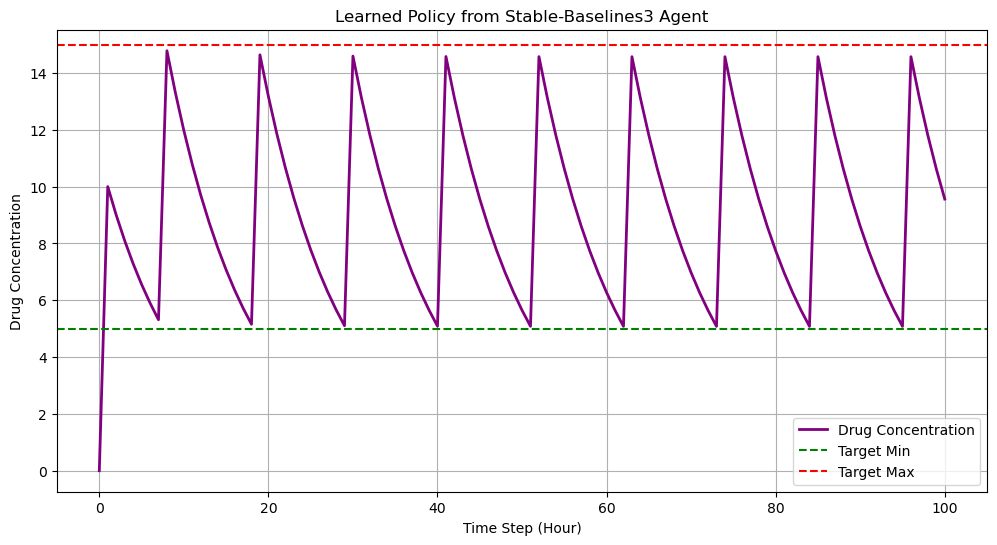

In [10]:
import matplotlib.pyplot as plt
import numpy as np

obs, info = env.reset() 
concentrations = [obs[0]] # Store the history of concentrations

print("--- Running simulation with the trained agent ---")
for _ in range(env.max_steps):
    
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    concentrations.append(obs[0])
    
    if terminated or truncated:
        break

plt.figure(figsize=(12, 6))
plt.plot(concentrations, label='Drug Concentration', color='purple', linewidth=2)
plt.axhline(y=env.target_min, color='green', linestyle='--', label='Target Min')
plt.axhline(y=env.target_max, color='red', linestyle='--', label='Target Max')
plt.title("Learned Policy from Stable-Baselines3 Agent")
plt.xlabel("Time Step (Hour)")
plt.ylabel("Drug Concentration")
plt.legend()
plt.grid(True)
plt.show()